# Ch 11 — 피마 인디언 당뇨병 예측

원본: `02_Data_preparation.py` (EDA) + `02_Pima_Indian.py` (학습)

다루는 내용:
1. 데이터 로드 + 컬럼 이름
2. EDA — head / info / describe
3. 상관관계 히트맵
4. plasma 분포 비교 (class별)
5. 모델 학습 (Dense 12-8-1)

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

import seaborn as sns

2026-05-12 13:08:38.150001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778558918.167436 1462572 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778558918.173027 1462572 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 로드 (컬럼 이름 부여)

In [2]:
DATA = "../../data/pima-indians-diabetes.csv"
columns = ["pregnant", "plasma", "pressure", "thickness",
           "insulin", "BMI", "pedigree", "age", "class"]
df = pd.read_csv(DATA, names=columns)
print("shape:", df.shape)
df.head()

shape: (768, 9)


,pregnant,plasma,pressure,thickness,insulin,BMI,pedigree,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. 기본 통계

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   BMI        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   class      768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,pregnant,plasma,pressure,thickness,insulin,BMI,pedigree,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**관찰:** `plasma`, `pressure`, `thickness`, `insulin`, `BMI` 의 최솟값이 0인데, 이는 *결측 의미의 0*임. 진짜 0이 의학적으로 말이 안 되는 컬럼들. 책은 이 부분을 다루지 않지만, 실무에선 대치(impute)가 필요.

## 3. 상관관계 히트맵

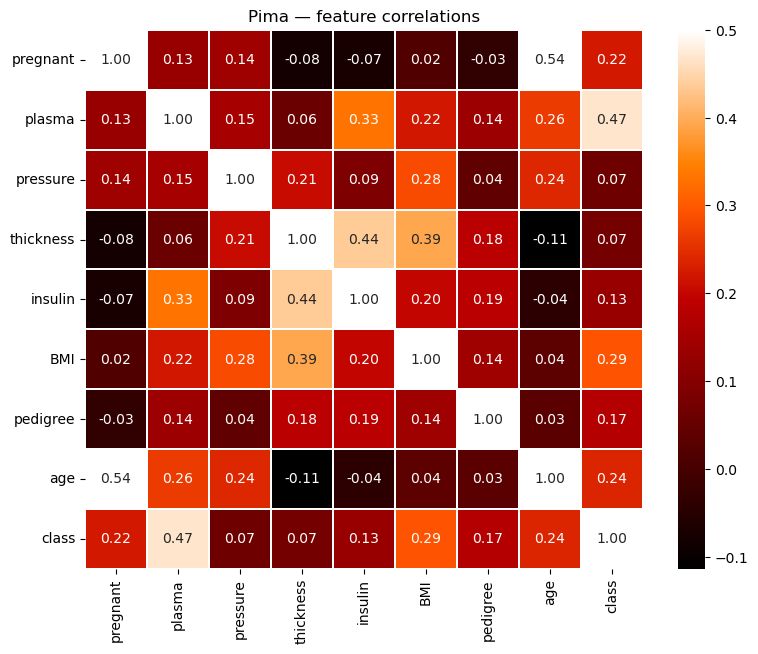

In [5]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f",
            cmap="gist_heat", linewidths=0.1, vmax=0.5, linecolor="white")
plt.title("Pima — feature correlations")
plt.show()

## 4. plasma — 클래스별 분포

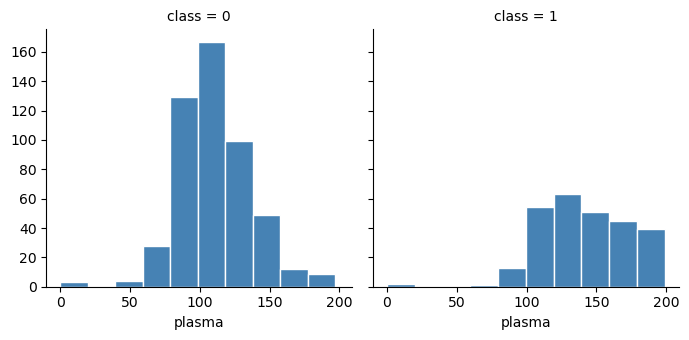

In [6]:
g = sns.FacetGrid(df, col="class", height=3.5)
g.map(plt.hist, "plasma", bins=10, color="steelblue", edgecolor="white")
plt.show()

당뇨 발병군(`class=1`)이 비발병군(`class=0`)보다 plasma 분포가 오른쪽으로 이동.
이것이 `class` 와 `plasma` 의 양의 상관관계를 시각적으로 확인하는 방법.

## 5. 학습용 X/y 분리

In [7]:
X = df.iloc[:, 0:8].to_numpy(dtype="float32")
y = df["class"].to_numpy(dtype="float32")
print("X:", X.shape, "y:", y.shape)
print("y 분포:", np.bincount(y.astype(int)))

X: (768, 8) y: (768,)
y 분포: [500 268]


## 6. 모델 — Dense(12) → Dense(8) → Dense(1)

In [8]:
def build_model():
    return Sequential([
        Input(shape=(8,)),
        Dense(12, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

keras.utils.set_random_seed(0)
model = build_model()
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

2026-05-12 13:08:41.032718: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. 학습

In [9]:
hist = model.fit(X, y, epochs=200, batch_size=10, verbose=0)
print(f"final train accuracy: {hist.history['accuracy'][-1]:.4f}")

final train accuracy: 0.7773


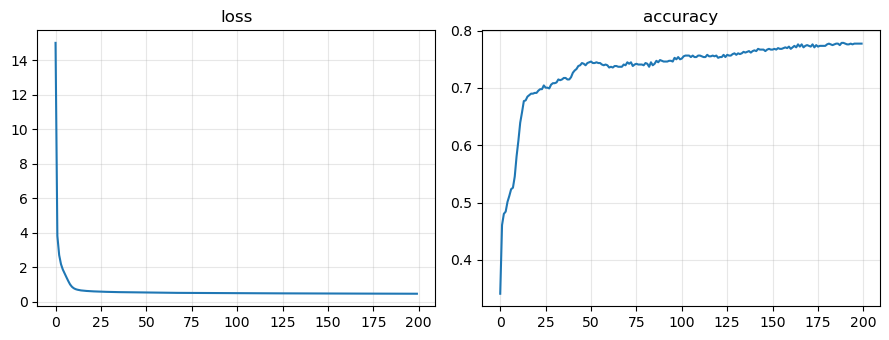

In [10]:
plt.figure(figsize=(9, 3.5))
plt.subplot(1, 2, 1); plt.plot(hist.history["loss"]); plt.title("loss"); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2); plt.plot(hist.history["accuracy"]); plt.title("accuracy"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. 평가

In [11]:
loss, acc = model.evaluate(X, y, verbose=0)
print(f"loss = {loss:.4f}, accuracy = {acc:.4f}")

loss = 0.4669, accuracy = 0.7760


## 마무리
- [ ] 0이 들어간 컬럼을 NaN으로 바꾼 뒤 평균 대치하면 정확도가 어떻게 바뀌는가?
- [ ] hidden layer 크기를 바꾸면? (12→24, 8→16)
- [ ] Train accuracy가 0.85+ 나와도, *학습 데이터 그대로 평가*한 결과라는 점 인지